In [1]:


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Are there any missing values or duplicate Invoice IDs? How would you handle them?
df = pd.read_csv('data/WalmartSalesData.csv')
missing_values = df.isnull().sum()

In [3]:
#What's the distribution of Unit price and Quantity — any outliers?
df[['Unit price', 'Quantity']].describe()

,Unit price,Quantity
count,1000.000000,1000.000000
mean,55.672130,5.510000
std,26.494628,2.923431
min,10.080000,1.000000
25%,32.875000,3.000000
50%,55.230000,5.000000
75%,77.935000,8.000000
max,99.960000,10.000000


In [4]:
# Is there a correlation between Rating and Total spend?
df[['Rating','Total']].corr()

# I see there is almost 0 correlation values, seems there is no relation between those two

,Rating,Total
Rating,1.000000,-0.036442
Total,-0.036442,1.000000


In [5]:
# Does Customer type (Member/Normal) show different average spending behavior?
df.groupby(['Customer type'])['Total'].mean()

# Memeber customer have slightly higher average spending compared to noraml customer

Customer type
Member    327.791305
Normal    318.122856
Name: Total, dtype: float64

In [6]:
# What time of day sees the most transactions? (extract hour from Time)
df['Date'] = pd.to_datetime(df['Date'])

result = (
    df.groupby([
        df['Date'].dt.year.rename('Year'),
        df['Date'].dt.day.rename('Day'),
        df['Time'].dt.hour.rename('Hour')
    ])
    .size()
    .reset_index(name='Transactions')
    .sort_values('Transactions', ascending=False)
)

result

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
# Which day of the week has the highest sales volume?
df['Day_of_Week'] = pd.to_datetime(df['Time'], errors='coerce').dt.day_name()

sales_by_day = (df.groupby('Day_of_Week')['Quantity']
                .sum()
                .reset_index()
                .sort_values(by='Quantity', ascending=False))

print(sales_by_day)

  Day_of_Week  Quantity
0   Wednesday      5510


/var/folders/z0/qkkxs6tn6gj7f73k8kr5l63c0000gn/T/ipykernel_14620/2779590542.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Day_of_Week'] = pd.to_datetime(df['Time'], errors='coerce').dt.day_name()


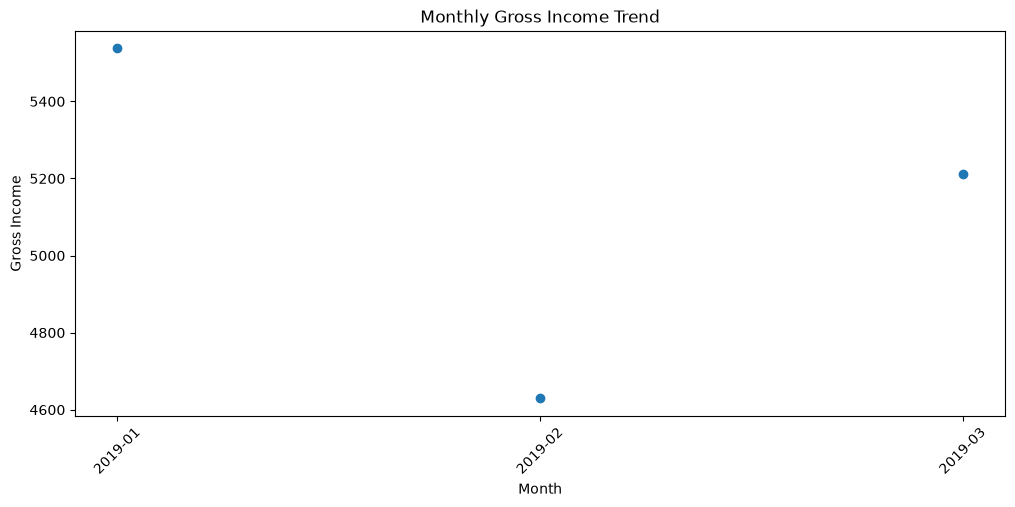

In [ ]:
# Visualize gross income trend over the observed months — any seasonality?
df['Date']=pd.to_datetime(df['Date'])
monthly_income=(
    df.groupby(df['Date'].dt.to_period('M'))['gross income']
    .sum()
    .reset_index()
)
monthly_income['Date']=monthly_income['Date'].astype(str)


plt.figure(figsize=(12,5))

plt.scatter(
    monthly_income['Date'],
    monthly_income['gross income']
)

plt.title('Monthly Gross Income Trend')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Gross Income')

plt.show()

<Figure size 1600x1200 with 0 Axes>

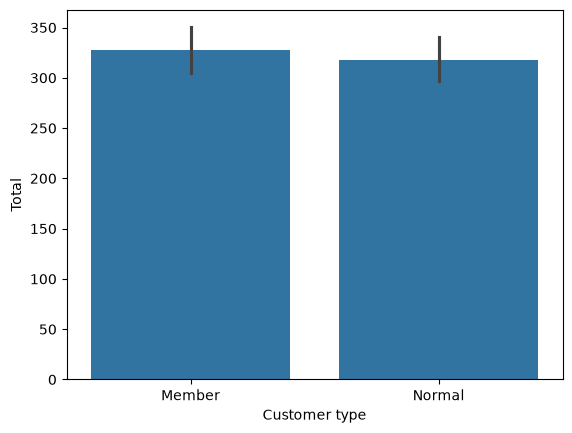

<Figure size 1600x1200 with 0 Axes>

In [ ]:
sns.barplot(data=df, x='Customer type', y='Total')
plt.figure(figsize=(16,12))

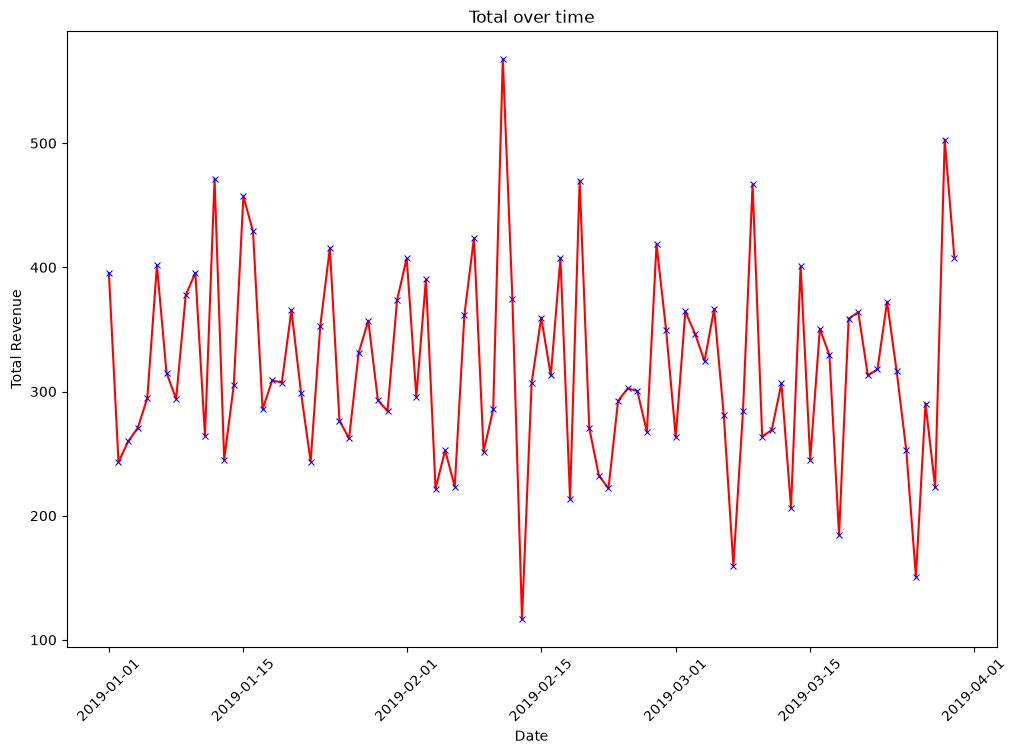

In [14]:
plt.figure(figsize=(12,8))
sns.lineplot(
    data=df,
    x='Date',
    y='Total',
    color='red',
    marker='x',
    markersize=4,
    markeredgecolor='blue',
    errorbar=None

)
plt.title('Total over time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [10]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')